In [1]:
import pandas as pd

In [2]:
cd ..

C:\Users\aarus\Desktop\College\Projects\Credit-Risk-Decision-Engine


In [3]:
df = pd.read_csv('data/data_imputation_train.csv')
val_df = pd.read_csv('data/data_imputation_val.csv')
test_df = pd.read_csv('data/data_imputation_test.csv')
df.head()

,loan_amnt,term,int_rate,sub_grade,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,...,has_recent_inq,dti_was_missing,revol_util_was_missing,emp_length_was_missing,is_thin_file,has_modern_metrics,emp_unemployment_risk,rev_bal_to_inc,credit_hist_age_mths,target
0,3600.0,36 months,13.99,C4,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,...,1,0,0,0,0,1,5.0,0.050272,148,0
1,24700.0,36 months,11.99,C1,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,...,1,0,0,0,0,1,5.0,0.330303,192,0
2,20000.0,60 months,10.78,B4,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,...,1,0,0,0,0,1,5.0,0.124903,184,0
3,10400.0,60 months,22.45,F1,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,...,1,0,0,0,0,1,40.0,0.209980,210,0
4,11950.0,36 months,13.44,C3,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,...,0,0,0,0,0,1,35.0,0.259463,338,0


In [11]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'sub_grade', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti',
       'delinq_2yrs', 'fico_range_low', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'chargeoff_within_12_mths',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_

In [4]:
y_train = df['target']
X_train = df.drop(columns = ['target'])

y_val = val_df['target']
X_val = val_df.drop(columns = ['target'])

y_test = test_df['target']
X_test = test_df.drop(columns = ['target'])

In [5]:
X_train.select_dtypes(exclude=['number']).columns.tolist()

['term',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type']

In [6]:
def convert_ordinal_data(df):
    df['term'] = df['term'].str.extract(r'(\d+)').astype(int)

    sub_grade_mapping = {
    'A1': 1, 'A2': 2, 'A3': 3, 'A4': 4, 'A5': 5,
    'B1': 6, 'B2': 7, 'B3': 8, 'B4': 9, 'B5': 10,
    'C1': 11, 'C2': 12, 'C3': 13, 'C4': 14, 'C5': 15,
    'D1': 16, 'D2': 17, 'D3': 18, 'D4': 19, 'D5': 20,
    'E1': 21, 'E2': 22, 'E3': 23, 'E4': 24, 'E5': 25,
    'F1': 26, 'F2': 27, 'F3': 28, 'F4': 29, 'F5': 30,
    'G1': 31, 'G2': 32, 'G3': 33, 'G4': 34, 'G5': 35
}
    df['sub_grade'] = df['sub_grade'].map(sub_grade_mapping)

    verif_mapping = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
    df['verification_status'] = df['verification_status'].map(verif_mapping)

    df['initial_list_status'] = (df['initial_list_status'] == 'w').astype(int)
    df['application_type'] = (df['application_type'] == 'Individual').astype(int)

    df = pd.get_dummies(df, columns=['home_ownership', 'purpose'], drop_first=True)

    return df

In [7]:
X_train = convert_ordinal_data(X_train)
X_val = convert_ordinal_data(X_val)
X_test = convert_ordinal_data(X_test)

In [8]:
# Using target encoder instead of one-hot-encoding to avoid creating 50 new columns
state_map = y_train.groupby(X_train['addr_state']).mean()
for df in [X_train, X_val, X_test]:
    df['state_risk_score'] = df['addr_state'].map(state_map)

X_train.drop(columns=['addr_state'], inplace=True)
X_val.drop(columns=['addr_state'], inplace=True)
X_test.drop(columns=['addr_state'], inplace=True)

In [9]:
# Aligning columns across dataset
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# Normalizing the number features
scaler = StandardScaler()
cols = X_train.columns

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=cols)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=cols)

In [14]:
X_train.shape

(1119711, 93)

### VIF

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [16]:
X_sample = X_train_scaled.sample(n=50000, random_state=42)

vif_data = pd.DataFrame()
vif_data["feature"] = X_sample.columns
vif_data["VIF"] = [variance_inflation_factor(X_sample.values, i) for i in range(len(X_sample.columns))]

In [17]:
print(vif_data.sort_values(by="VIF", ascending=False).head(15))

                       feature           VIF
74     home_ownership_MORTGAGE  12513.564046
78         home_ownership_RENT  12065.719062
77          home_ownership_OWN   4680.215547
3                    sub_grade     37.204248
2                     int_rate     36.870004
80  purpose_debt_consolidation     22.649381
15                   total_acc     22.514453
66             dti_was_missing     18.055317
79         purpose_credit_card     16.911438
50               num_rev_accts     13.779685
13                     pub_rec     13.377156
49                   num_il_tl     10.339586
69                is_thin_file      7.818762
59             tot_hi_cred_lim      7.266913
58                   tax_liens      6.782282


In [21]:
vif_drops = ['int_rate', 'total_acc', 'dti_was_missing', 'home_ownership_MORTGAGE', 
             'purpose_debt_consolidation','pub_rec']
X_train_scaled = X_train_scaled.drop(columns=vif_drops, errors='ignore')
X_val_scaled = X_val_scaled.drop(columns=vif_drops, errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=vif_drops, errors='ignore')

In [22]:
X_train_scaled.shape

(1119711, 87)

In [23]:
y_train.value_counts()/len(y_train)

target
0    0.803024
1    0.196976
Name: count, dtype: float64

## Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

In [25]:
model = LogisticRegression(class_weight='balanced', solver='saga', max_iter=1000, warm_start=True, verbose=0, n_jobs=8)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=8,
                   solver='saga', warm_start=True)

In [26]:
y_pred = model.predict(X_val_scaled)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.51      0.65     70024
           1       0.33      0.78      0.46     21342

    accuracy                           0.58     91366
   macro avg       0.61      0.65      0.56     91366
weighted avg       0.76      0.58      0.61     91366



In [27]:
y_probs = model.predict_proba(X_val_scaled)[:, 1]

new_threshold = 0.6
y_pred_adjusted = (y_probs >= new_threshold).astype(int)

print(classification_report(y_val, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.85      0.71      0.77     70024
           1       0.38      0.59      0.46     21342

    accuracy                           0.68     91366
   macro avg       0.61      0.65      0.62     91366
weighted avg       0.74      0.68      0.70     91366



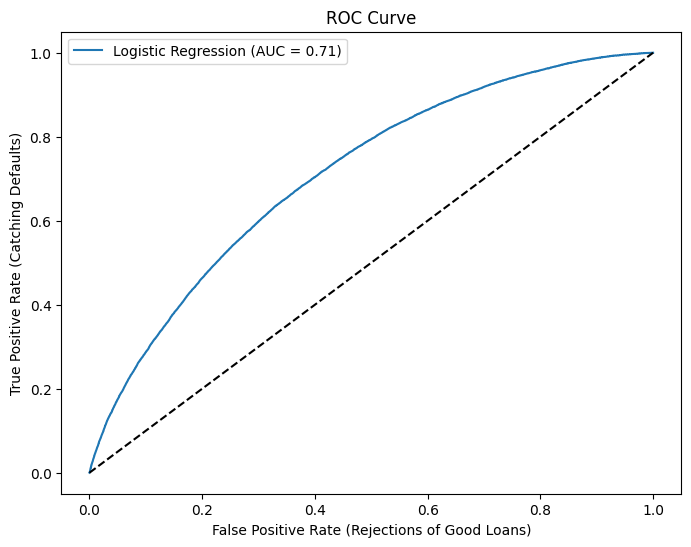

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, y_probs)
auc_score = roc_auc_score(y_val, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal line (random guessing)
plt.xlabel('False Positive Rate (Rejections of Good Loans)')
plt.ylabel('True Positive Rate (Catching Defaults)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [30]:
import numpy as np
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_probs)

# Calculate Youden's J Statistic: J = TPR - FPR
# We want to maximize the difference between catching bad loans and missing good ones
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")

y_pred_opt = (y_probs >= best_threshold).astype(int)
print("\nOptimized Classification Report")
print(classification_report(y_val, y_pred_opt))

Optimal Threshold: 0.5538

Optimized Classification Report
              precision    recall  f1-score   support

           0       0.87      0.62      0.72     70024
           1       0.36      0.68      0.47     21342

    accuracy                           0.64     91366
   macro avg       0.61      0.65      0.60     91366
weighted avg       0.75      0.64      0.66     91366



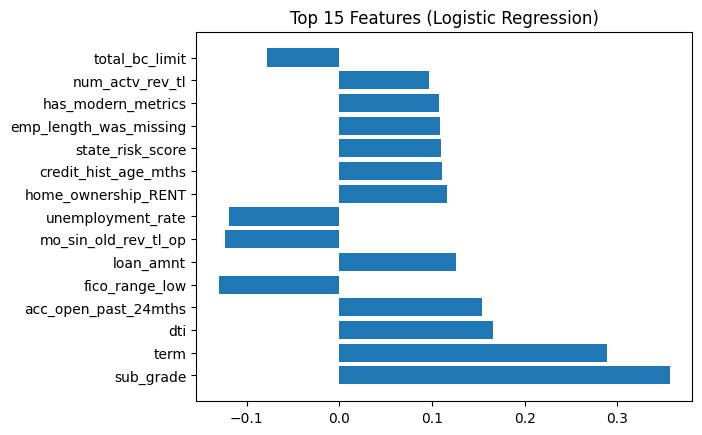

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_[0]
})

importance['abs_val'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='abs_val', ascending=False).head(15)

plt.barh(importance['Feature'], importance['Coefficient'])
plt.title("Top 15 Features (Logistic Regression)")
plt.show()

## LightGBM

In [10]:
import lightgbm as lgb

In [11]:
train_data = lgb.Dataset(X_train, label=y_train)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'is_unbalance': True,  # LightGBM's version of class_weight='balanced'
    'learning_rate': 0.05,
    'verbosity': -1,
    'seed': 42
}
lgbm_model = lgb.train(params, train_data, num_boost_round=500)

NameError: name 'X_val_final' is not defined

In [14]:
lgbm_probs = lgbm_model.predict(X_val)
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print(classification_report(y_val, lgbm_preds))

              precision    recall  f1-score   support

           0       0.89      0.53      0.67     70024
           1       0.34      0.78      0.47     21342

    accuracy                           0.59     91366
   macro avg       0.61      0.66      0.57     91366
weighted avg       0.76      0.59      0.62     91366



C:\Users\aarus\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


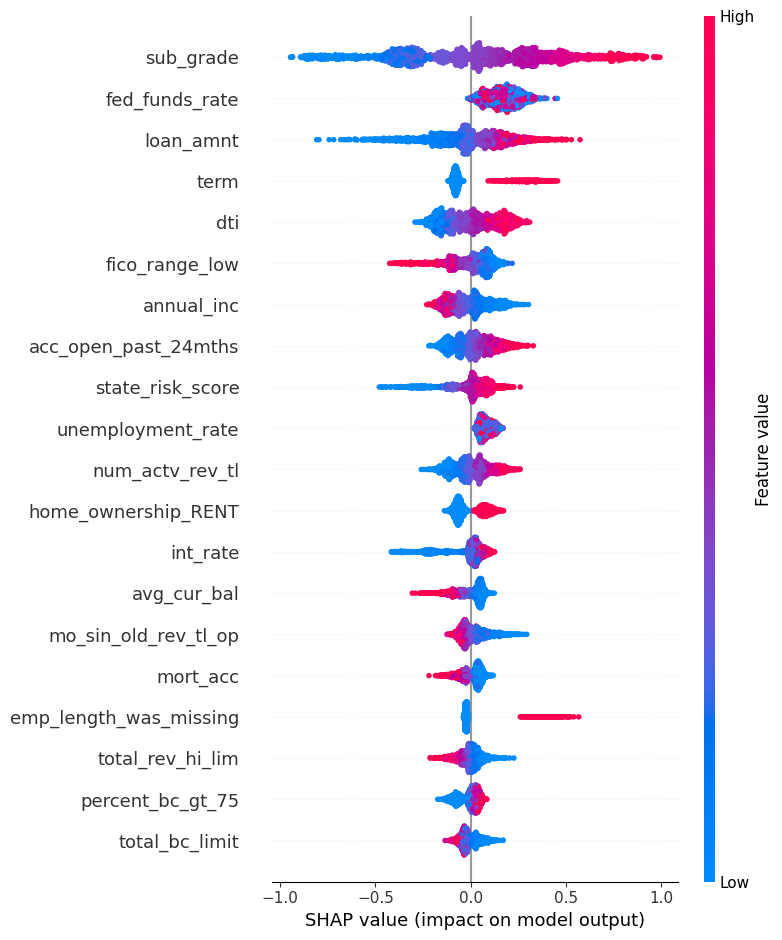

In [18]:
import shap
import numpy as np

explainer = shap.TreeExplainer(lgbm_model)
X_sample = X_val.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

shap.summary_plot(shap_to_plot, X_sample)

In [21]:
# Updated Parameters for better class separation
params = {
    'objective': 'binary',
    'metric': 'auc',
    'is_unbalance': True,
    'learning_rate': 0.02,     # Slower learning for more precision
    'num_leaves': 64,          # More complex trees
    'feature_fraction': 0.7,   # Prevent overfitting on one feature
    'min_data_in_leaf': 100,   # Ensure splits are meaningful
    'verbosity': -1,
    'seed': 42
}

# Re-train
lgbm_model_v2 = lgb.train(params, train_data, num_boost_round=1000)
lgbm_probs_v2 = lgbm_model_v2.predict(X_val)

# Use a fixed threshold that we KNOW works for balanced models: 0.5
# Or better yet, try 0.45 to be slightly more sensitive to risk
final_preds_v2 = (lgbm_probs_v2 >= 0.5).astype(int)
print(classification_report(y_val, final_preds_v2))

              precision    recall  f1-score   support

           0       0.89      0.54      0.67     70024
           1       0.34      0.78      0.47     21342

    accuracy                           0.59     91366
   macro avg       0.61      0.66      0.57     91366
weighted avg       0.76      0.59      0.62     91366



In [25]:
from sklearn.metrics import recall_score, precision_score

In [26]:
# Manually test a range of thresholds that actually exist in your data
for t in [0.4, 0.5, 0.6, 0.7]:
    preds = (lgbm_probs >= t).astype(int)
    recall_1 = recall_score(y_val, preds)
    precision_1 = precision_score(y_val, preds)
    print(f"Threshold {t}: Recall={recall_1:.2f}, Precision={precision_1:.2f}")

Threshold 0.4: Recall=0.90, Precision=0.30
Threshold 0.5: Recall=0.78, Precision=0.34
Threshold 0.6: Recall=0.61, Precision=0.39
Threshold 0.7: Recall=0.37, Precision=0.47


In [4]:
import joblib
model = joblib.load('Models/optimized_credit_risk_model.joblib')

feature_names = loaded_model.get_feature_names_out()
print(feature_names)

C:\Users\aarus\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\aarus\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


AttributeError: module 'sklearn.compose._column_transformer' has no attribute '_RemainderColsList'

In [2]:
cd ..

C:\Users\aarus\Desktop\College\Courses\Credit-Risk-Decision-Engine
